In [ ]:
import os
import sys

In [ ]:
import os
import rpy2.robjects as robjects

from rpy2.robjects import pandas2ri, default_converter, conversion

import torch
import pyro
from rpy2.robjects import r, vectors
from rpy2 import rinterface

Error importing in API mode: ImportError("dlopen(/Users/jonathanhori/opt/anaconda3/envs/multiomic/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <20FB70DB-7E84-3375-A520-E0350E06C060> /Users/jonathanhori/opt/anaconda3/envs/multiomic/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.
Trying to import in ABI mode.
/Users/jonathanhori/opt/anaconda3/envs/multiomic/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipyw

In [ ]:
conversion._converter = None
conversion.set_conversion(default_converter)
readRDS = robjects.r['readRDS']

# sim_data = readRDS('~/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/sim/simple_data/factor_data_n1000p500_snr2.2.rds')
sim_data = readRDS('~/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/sim/simple_data/factor_data_n2000p10000_snr2.2.rds')

In [ ]:
print(sim_data)

[[1]]
                 [,1]          [,2]          [,3]         [,4]          [,5]
   [1,]   2.000626355 -3.477306e-01   2.720289059  1.533793731  3.0735515480
   [2,]  -5.329620451  1.995070e-01   2.434852184  1.242547119  0.8174570848
   [3,]   1.982776917 -5.433712e-01  -3.211029207  2.160917071  0.1624330709
   [4,]  -3.024276261 -8.949415e-01   0.585111825  0.335141515 -2.4143756752
   [5,]   7.554782929  2.309703e+00  -1.762463448 -3.903154961  4.0339286819
   [6,]  -3.947356319  8.383832e-01  -2.264012590 -1.444078972  0.6626258544
   [7,]  -2.839094376  9.717354e-01  -5.409079431 -0.812387578  2.1759543822
   [8,]   0.414175856 -1.622567e+00   4.814914918 -1.106133034 -2.5336519453
   [9,]   2.795393691 -4.335381e-01   1.163545957  2.564491662  1.5147208826
                 [,6]         [,7]          [,8]         [,9]         [,10]
   [1,]   1.211184448 -0.288365631   1.085147116 -0.400313994 -4.607251e-01
   [2,]   0.153424855 -0.950658869  -2.019660484  3.703645313 -3.586927e

In [ ]:
def floatmatrix_to_torch(m):
    t = torch.tensor(list(m), dtype=torch.float32)
    # R matrices are stored column-major, so reshape and transpose
    t = t.view(m.ncol, m.nrow).t()
    return t

def r_to_torch(obj):
    """Recursively convert R objects (via rpy2) to Python/PyTorch equivalents."""
    
    # Case 1: R list (possibly named)
    if isinstance(obj, vectors.ListVector):
        names = getattr(obj, "names", None)
        if names is not None and not isinstance(names, rinterface.NULLType):
            return {name: r_to_torch(obj.rx2(name)) for name in names}
        else:
            return [r_to_torch(el) for el in obj]
    
    # Case 2: R matrix
    elif isinstance(obj, vectors.FloatMatrix):
        return floatmatrix_to_torch(obj)
    
    # Case 3: Numeric / integer / logical R vector
    elif isinstance(obj, (vectors.FloatSexpVector, vectors.IntSexpVector, vectors.BoolSexpVector)):
        return torch.tensor(list(obj), dtype=torch.float32)
    
    # Case 4: R data frame
    elif isinstance(obj, vectors.DataFrame):
        return {col: r_to_torch(obj.rx2(col)) for col in obj.names}
    
    # Case 5: Python list
    elif isinstance(obj, list):
        return [r_to_torch(el) for el in obj]
    
    # Case 6: R NULL
    elif isinstance(obj, rinterface.NULLType):
        return None
    
    # Fallback
    else:
        return obj

In [ ]:
conversion.set_conversion(default_converter)
sim_data_torch = {name: r_to_torch(sim_data.rx2(name)) for name in sim_data.names}

sim_data_torch

TypeError: 'NULLType' object is not iterable

In [ ]:
# conversion._converter = None
# conversion.set_conversion(default_converter)
# readRDS = robjects.r['readRDS']

# sim_data = readRDS('~/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/sim/simple_data/factor_data_n1000p500_snr2.2.rds')
sim_data = readRDS('~/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/sim/simple_data/factor_data_n2000p10000_snr2.2.rds')

NotImplementedError: 
    Conversion rules for `rpy2.robjects` appear to be missing. Those
    rules are in a Python `contextvars.ContextVar`. This could be caused
    by multithreading code not passing context to the thread.
    Check rpy2's documentation about conversions.
    

In [ ]:
conversion._converter = None
conversion.set_conversion(default_converter)
readRDS = robjects.r['readRDS']

# sim_data = readRDS('~/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/sim/simple_data/factor_data_n1000p500_snr2.2.rds')
sim_data = readRDS('~/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/sim/simple_data/factor_data_n2000p10000_snr2.2.rds')

In [ ]:
print(sim_data)

$L
[1] 1

$N
[1] 2000

$p_l
$p_l[[1]]
[1] 10000


$K
[1] 5

$K_l
[1] 5 5 5

$X_l
$X_l[[1]]
                 [,1]          [,2]          [,3]         [,4]          [,5]
   [1,]   2.000626355 -3.477306e-01   2.720289059  1.533793731  3.0735515480
   [2,]  -5.329620451  1.995070e-01   2.434852184  1.242547119  0.8174570848
   [3,]   1.982776917 -5.433712e-01  -3.211029207  2.160917071  0.1624330709
   [4,]  -3.024276261 -8.949415e-01   0.585111825  0.335141515 -2.4143756752
   [5,]   7.554782929  2.309703e+00  -1.762463448 -3.903154961  4.0339286819
   [6,]  -3.947356319  8.383832e-01  -2.264012590 -1.444078972  0.6626258544
   [7,]  -2.839094376  9.717354e-01  -5.409079431 -0.812387578  2.1759543822
   [8,]   0.414175856 -1.622567e+00   4.814914918 -1.106133034 -2.5336519453
   [9,]   2.795393691 -4.335381e-01   1.163545957  2.564491662  1.5147208826
                 [,6]         [,7]          [,8]         [,9]         [,10]
   [1,]   1.211184448 -0.288365631   1.085147116 -0.400313994 -

In [ ]:
conversion.set_conversion(default_converter)
sim_data_torch = {name: r_to_torch(sim_data.rx2(name)) for name in sim_data.names}

sim_data_torch

{'L': tensor([1.]),
 'N': tensor([2000.]),
 'p_l': [tensor([10000.])],
 'K': tensor([5.]),
 'K_l': tensor([5., 5., 5.]),
 'X_l': [tensor([[ 2.0006, -0.3477,  2.7203,  ...,  0.5184,  1.8881,  0.9304],
          [-5.3296,  0.1995,  2.4349,  ..., -2.1300, -2.9559, -2.9998],
          [ 1.9828, -0.5434, -3.2110,  ...,  0.3806,  0.0322, -2.5605],
          ...,
          [ 0.7288,  0.8981, -0.8337,  ...,  0.4623, -0.9262, -0.0720],
          [ 4.4166, -0.8608, -4.4817,  ...,  2.2394, -1.5992,  5.0410],
          [ 4.8755,  0.8066,  4.0590,  ...,  1.2901,  2.4593,  3.0063]])],
 'Lambda_l': [tensor([[-0.5605,  2.3707, -0.8363, -0.1936,  0.4825],
          [-0.2302, -0.1668, -0.2206,  0.2581,  0.7214],
          [ 1.5587,  0.9270, -2.1035, -0.5383, -0.5078],
          ...,
          [-0.7575,  0.9051, -0.1765,  0.5920,  0.1251],
          [ 1.0793,  1.8807, -0.1664, -0.7169, -0.0308],
          [-0.6449,  0.9296, -0.1135, -0.2664,  1.5910]])],
 'Z': tensor([[ 0.2596,  0.9175, -0.7223, -0.8083,

In [ ]:
X = sim_data_torch["X_l"][0]

In [ ]:
X.shape

torch.Size([2000, 10000])

In [ ]:
import importlib

In [ ]:
sys.path.insert(1, "/Users/jonathanhori/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/python")

In [ ]:
print(sys.path)

['/Users/jonathanhori/opt/anaconda3/envs/multiomic/lib/python311.zip', '/Users/jonathanhori/Library/Mobile Documents/com~apple~CloudDocs/Projects/multiomic_integration/python', '/Users/jonathanhori/opt/anaconda3/envs/multiomic/lib/python3.11', '/Users/jonathanhori/opt/anaconda3/envs/multiomic/lib/python3.11/lib-dynload', '', '/Users/jonathanhori/opt/anaconda3/envs/multiomic/lib/python3.11/site-packages']


In [ ]:
import importlib

In [ ]:
# importlib.reload(sys.modules["matrix_decomp"])
from matrix_decomp import bayesian_factor_model, train_decomp, predict_factor_model

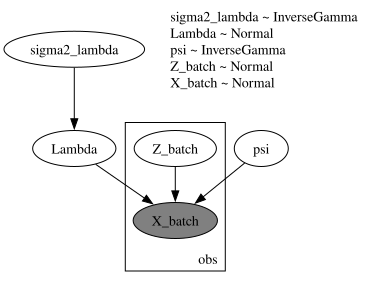

In [ ]:
# pyro.render_model(
#     bayesian_factor_model, 
#     model_args = (one_batch,
#                   5,
#                   one_batch[0].shape[0] #sim_data_torch["X_l"][0].shape[0] 
#     ),
#     render_distributions=True, 
#     render_params=True,
#     render_deterministic = True)

pyro.render_model(
    bayesian_factor_model, 
    model_args = (X,
                  5,
                  X.shape[0] #sim_data_torch["X_l"][0].shape[0] 
    ),
    render_distributions=True, 
    render_params=True,
    render_deterministic = True)

In [ ]:
# X = one_batch
k = 5
n = X.shape[0]

In [ ]:
import time

In [ ]:
pyro.clear_param_store()
t0 = time.time()
opt = train_decomp(X,
                   k, 
                   minibatch_flag = False,
                   tol = 1)
t1 = time.time()
run = t1 - t0

Iteration 0  loss: 47487.1774
Iteration 100  loss: 44006.2680
Iteration 200  loss: 39807.9861
Iteration 300  loss: 35730.2791
Iteration 400  loss: 32209.7737
Iteration 500  loss: 29242.1244
Iteration 600  loss: 26824.7962
Iteration 700  loss: 24907.3647
Iteration 800  loss: 23392.9253
Iteration 900  loss: 22254.8240
Iteration 1000  loss: 21360.9364
Iteration 1100  loss: 20700.7401
Iteration 1200  loss: 20175.0441
Iteration 1300  loss: 19791.1069
Iteration 1400  loss: 19473.5810
Iteration 1500  loss: 19200.6414
Iteration 1600  loss: 18996.3455
Iteration 1700  loss: 18830.3203
Iteration 1800  loss: 18689.9678
Iteration 1900  loss: 18571.5289
Iteration 2000  loss: 18482.8697
Iteration 2100  loss: 18396.8428
Iteration 2200  loss: 18331.2113
Iteration 2300  loss: 18267.7120
Iteration 2400  loss: 18221.7881
Iteration 2500  loss: 18177.0232
Iteration 2600  loss: 18137.7770
Iteration 2700  loss: 18105.5927
Iteration 2800  loss: 18073.8644
Iteration 2900  loss: 18049.9601
Iteration 3000  loss: 

In [ ]:
pyro.get_param_store().get_all_param_names()

dict_keys(['AutoNormal.locs.sigma2_lambda', 'AutoNormal.scales.sigma2_lambda', 'AutoNormal.locs.Lambda', 'AutoNormal.scales.Lambda', 'AutoNormal.locs.psi', 'AutoNormal.scales.psi', 'AutoNormal.locs.Z_batch', 'AutoNormal.scales.Z_batch'])

In [ ]:
pyro.get_param_store().save("rmf_ard.params_n2000p10000.save")

In [ ]:
print(run)

2153.941941022873
